# Netflix Engagement Analysis — Exploratory Data Analysis

This notebook explores viewing patterns and trends in Netflix's engagement data from 2023 H1 to 2026 H1.

In [79]:
import pandas as pd

In [80]:
df = pd.read_csv(
    "../data/processed/netflix_engagement_clean.csv"
)

In [81]:
df.shape

(115956, 9)

In [82]:
df.dtypes

Title                      str
Available Globally?        str
Release Date               str
Hours Viewed             int64
Runtime                    str
Views                  float64
Report Period              str
Content Type               str
Runtime Minutes        float64
dtype: object

In [83]:
df["Release Date"] = pd.to_datetime(
    df["Release Date"],
    errors="coerce"
)

df["Release Date"].dtype

dtype('<M8[us]')

In [84]:
df["Views"] = df["Views"].astype("Int64")

df["Views"].dtype

Int64Dtype()

In [85]:
df["Runtime Minutes"] = df["Runtime Minutes"].astype("Int64")

df["Runtime Minutes"].dtype

Int64Dtype()

In [86]:
df.head()

,Title,Available Globally?,Release Date,Hours Viewed,Runtime,Views,Report Period,Content Type,Runtime Minutes
0,The Night Agent: Season 1,Yes,2023-03-23,812100000,NaN,<NA>,2023 H1,NaN,<NA>
1,Ginny & Georgia: Season 2,Yes,2023-01-05,665100000,NaN,<NA>,2023 H1,NaN,<NA>
2,The Glory: Season 1 // 더 글로리: 시즌 1,Yes,2022-12-30,622800000,NaN,<NA>,2023 H1,NaN,<NA>
3,Wednesday: Season 1,Yes,2022-11-23,507700000,NaN,<NA>,2023 H1,NaN,<NA>
4,Queen Charlotte: A Bridgerton Story,Yes,2023-05-04,503000000,NaN,<NA>,2023 H1,NaN,<NA>


How much Netflix viewing was recorded in each six-month reporting period?

In [87]:
hours_by_period = (
    df.groupby("Report Period")["Hours Viewed"]
    .sum()
)

hours_by_period

Report Period
2023 H1    93455200000
2023 H2    90023100000
2024 H1    94003500000
2024 H2    94115100000
2025 H1    95186500000
2025 H2    96207800000
2026 H1    97664500000
Name: Hours Viewed, dtype: int64

In [88]:
hours_by_period_billions = hours_by_period / 1_000_000_000

hours_by_period_billions

Report Period
2023 H1    93.4552
2023 H2    90.0231
2024 H1    94.0035
2024 H2    94.1151
2025 H1    95.1865
2025 H2    96.2078
2026 H1    97.6645
Name: Hours Viewed, dtype: float64

In [89]:
import matplotlib.pyplot as plt

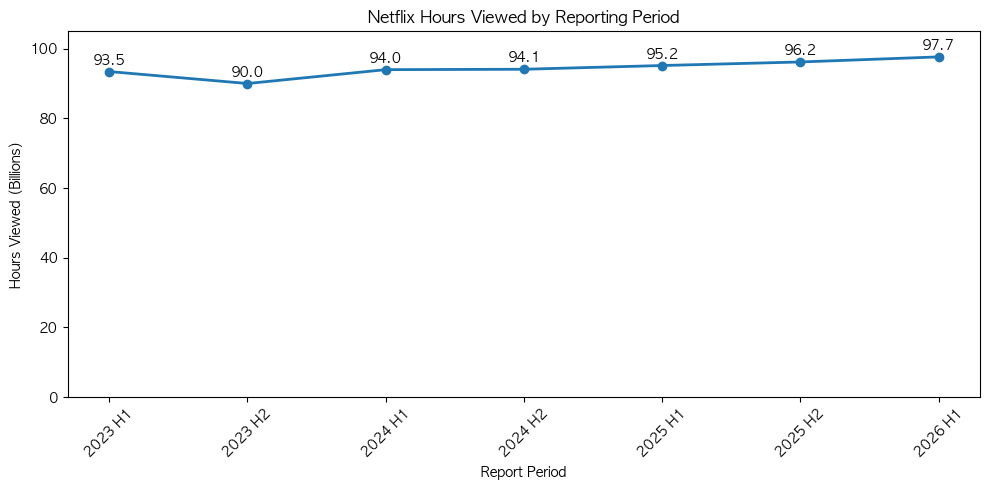

In [90]:
plt.figure(figsize=(10, 5))

plt.plot(
    hours_by_period_billions.index,
    hours_by_period_billions.values,
    marker="o",
    linewidth=2
)

plt.title("Netflix Hours Viewed by Reporting Period")
plt.xlabel("Report Period")
plt.ylabel("Hours Viewed (Billions)")

plt.ylim(0, 105)

for period, value in hours_by_period_billions.items():
    plt.text(
        period,
        value + 2,
        f"{value:.1f}",
        ha="center"
    )

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [91]:
hours_by_period_billions.pct_change() * 100

Report Period
2023 H1         NaN
2023 H2   -3.672455
2024 H1    4.421532
2024 H2    0.118719
2025 H1    1.138393
2025 H2    1.072946
2026 H1    1.514118
Name: Hours Viewed, dtype: float64

In [92]:
overall_change = (
    (hours_by_period_billions.iloc[-1] / hours_by_period_billions.iloc[0]) - 1
) * 100

print(f"{overall_change:.1f}%")

4.5%


### Viewing Hours Trend

Total reported viewing hours fell by 3.7% from 2023 H1 to 2023 H2, before rebounding by 4.4% in 2024 H1. Viewing hours then increased in every subsequent reporting period, reaching approximately 97.7 billion hours in 2026 H1.

Overall, reported viewing hours increased by approximately 4.5% between 2023 H1 and 2026 H1.

These results should be interpreted with care because changes in Netflix's reporting methodology may affect direct comparisons between reporting periods.

Which individual titles generated the most viewing?

In [93]:
top_10_titles = (
    df.nlargest(10, "Hours Viewed")
    [["Title", "Hours Viewed", "Report Period"]]
)

top_10_titles

,Title,Hours Viewed,Report Period
82114,Wednesday: Season 2,964100000,2025 H2
98585,Bridgerton: Season 4,889800000,2026 H1
82115,Stranger Things 5,879700000,2025 H2
65933,Squid Game: Season 2 // 오징어 게임: 시즌 2,840300000,2025 H1
0,The Night Agent: Season 1,812100000,2023 H1
89860,KPop Demon Hunters,802600000,2025 H2
106777,Other Shows,757000000,2026 H1
34209,Bridgerton: Season 3,733800000,2024 H1
34208,Fool Me Once: Limited Series,689500000,2024 H1
34221,Queen of Tears: Limited Series // 눈물의 여왕: 리미티드...,682600000,2024 H1


In [94]:
df_titles = df[
    ~df["Title"].isin(["Other Shows", "Other Movies"])
].copy()

df_titles.shape

(115952, 9)

In [95]:
top_10_titles = (
    df_titles.nlargest(10, "Hours Viewed")
    [["Title", "Hours Viewed", "Report Period"]]
)

top_10_titles

,Title,Hours Viewed,Report Period
82114,Wednesday: Season 2,964100000,2025 H2
98585,Bridgerton: Season 4,889800000,2026 H1
82115,Stranger Things 5,879700000,2025 H2
65933,Squid Game: Season 2 // 오징어 게임: 시즌 2,840300000,2025 H1
0,The Night Agent: Season 1,812100000,2023 H1
89860,KPop Demon Hunters,802600000,2025 H2
34209,Bridgerton: Season 3,733800000,2024 H1
34208,Fool Me Once: Limited Series,689500000,2024 H1
34221,Queen of Tears: Limited Series // 눈물의 여왕: 리미티드...,682600000,2024 H1
1,Ginny & Georgia: Season 2,665100000,2023 H1


In [96]:
top_10_titles = top_10_titles.copy()

top_10_titles["Hours Viewed (Millions)"] = (
    top_10_titles["Hours Viewed"] / 1_000_000
)

top_10_titles[
    ["Title", "Hours Viewed (Millions)", "Report Period"]
]

,Title,Hours Viewed (Millions),Report Period
82114,Wednesday: Season 2,964.1,2025 H2
98585,Bridgerton: Season 4,889.8,2026 H1
82115,Stranger Things 5,879.7,2025 H2
65933,Squid Game: Season 2 // 오징어 게임: 시즌 2,840.3,2025 H1
0,The Night Agent: Season 1,812.1,2023 H1
89860,KPop Demon Hunters,802.6,2025 H2
34209,Bridgerton: Season 3,733.8,2024 H1
34208,Fool Me Once: Limited Series,689.5,2024 H1
34221,Queen of Tears: Limited Series // 눈물의 여왕: 리미티드...,682.6,2024 H1
1,Ginny & Georgia: Season 2,665.1,2023 H1


Text(0, 0.5, 'Title')

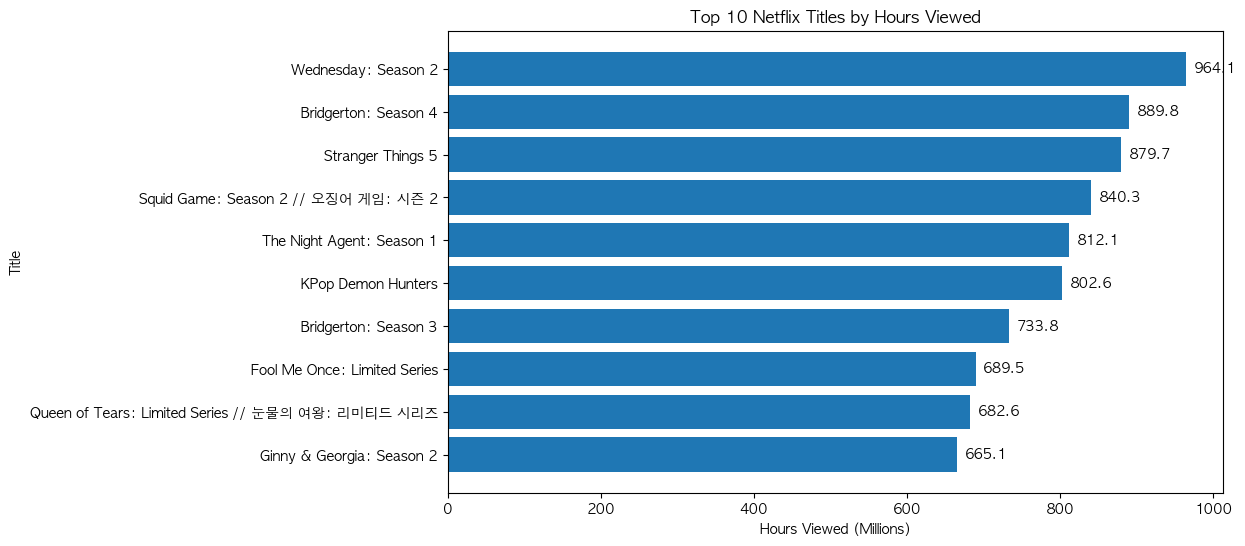

In [97]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_10_titles["Title"][::-1],
    top_10_titles["Hours Viewed (Millions)"][::-1]
)

for title, value in zip(
    top_10_titles["Title"][::-1],
    top_10_titles["Hours Viewed (Millions)"][::-1]
):
    plt.text(
        value + 10,
        title,
        f"{value:.1f}",
        va="center"
    )

plt.title("Top 10 Netflix Titles by Hours Viewed")
plt.xlabel("Hours Viewed (Millions)")
plt.ylabel("Title")

In [98]:
import matplotlib.font_manager as fm

[
    f.name for f in fm.fontManager.ttflist
    if "AppleGothic" in f.name or "Noto Sans CJK" in f.name
]

['AppleGothic']

In [99]:
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False

### Top Titles by Hours Viewed

Wednesday: Season 2 recorded the highest single-period viewing total in the dataset, with approximately 964.1 million hours viewed in 2025 H2. Bridgerton: Season 4 and Stranger Things 5 followed with 889.8 million and 879.7 million hours respectively.

The ranking represents individual title-period observations rather than cumulative viewing across multiple reporting periods.

How concentrated is Netflix viewing? Do a relatively small number of titles account for a large share of total viewing?

In [100]:
total_title_hours = df_titles["Hours Viewed"].sum()

print(f"{total_title_hours / 1_000_000_000:.1f} billion hours")

659.0 billion hours


In [101]:
top_10_hours = top_10_titles["Hours Viewed"].sum()

top_10_share = (
    top_10_hours / total_title_hours
) * 100

print(f"{top_10_share:.1f}%")

1.2%


In [102]:
top_1_percent_n = round(len(df_titles) * 0.01)

top_1_percent_n

1160

In [103]:
top_1_percent_hours = (
    df_titles.nlargest(top_1_percent_n, "Hours Viewed")["Hours Viewed"]
    .sum()
)

top_1_percent_share = (
    top_1_percent_hours / total_title_hours
) * 100

print(f"{top_1_percent_share:.1f}%")

24.8%


In [104]:
top_5_percent_n = round(len(df_titles) * 0.05)

top_5_percent_n

5798

In [105]:
top_5_percent_hours = (
    df_titles.nlargest(top_5_percent_n, "Hours Viewed")["Hours Viewed"]
    .sum()
)

top_5_percent_share = (
    top_5_percent_hours / total_title_hours
) * 100

print(f"{top_5_percent_share:.1f}%")

52.8%


In [106]:
top_10_percent_n = round(len(df_titles) * 0.10)

top_10_percent_n

11595

In [107]:
top_10_percent_hours = (
    df_titles.nlargest(top_10_percent_n, "Hours Viewed")["Hours Viewed"]
    .sum()
)

top_10_percent_share = (
    top_10_percent_hours / total_title_hours
) * 100

print(f"{top_10_percent_share:.1f}%")

68.6%


In [108]:
concentration = pd.Series({
    "Top 1%": top_1_percent_share,
    "Top 5%": top_5_percent_share,
    "Top 10%": top_10_percent_share
})

concentration

Top 1%     24.830503
Top 5%     52.773662
Top 10%    68.587743
dtype: float64

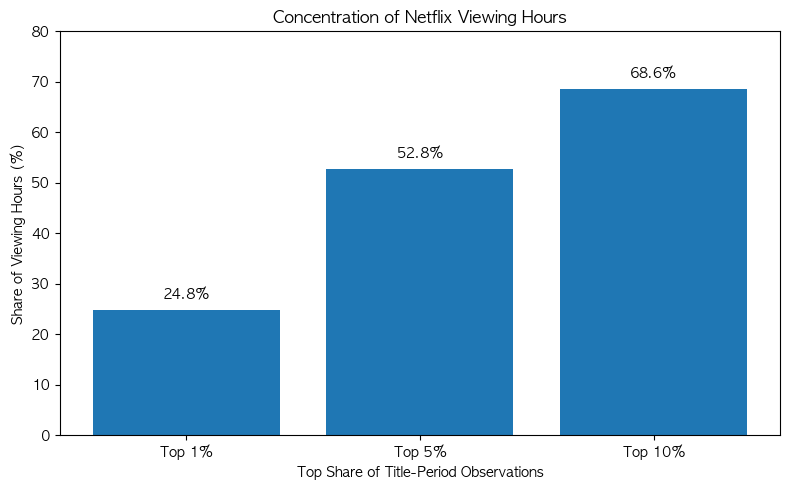

In [109]:
plt.figure(figsize=(8, 5))

plt.bar(
    concentration.index,
    concentration.values
)

plt.title("Concentration of Netflix Viewing Hours")
plt.xlabel("Top Share of Title-Period Observations")
plt.ylabel("Share of Viewing Hours (%)")

plt.ylim(0, 80)

for label, value in concentration.items():
    plt.text(
        label,
        value + 2,
        f"{value:.1f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Viewing Concentration

Netflix viewing is highly concentrated among the most-watched title-period observations. The top 1% of observations account for approximately 24.8% of total title-level viewing hours, while the top 5% account for 52.8%.

The concentration becomes even clearer at the top 10%, which accounts for approximately 68.6% of viewing hours. This indicates that a relatively small proportion of Netflix content observations generates the majority of reported viewing.

These figures are based on title-period observations rather than unique titles, as the same title may appear in multiple reporting periods.

How does Netflix engagement differ between Movies and Shows?

In [110]:
df_titles["Content Type"].value_counts()

Content Type
Movie    54009
Show     43729
Name: count, dtype: int64

In [111]:
hours_by_type = (
    df_titles.groupby("Content Type")["Hours Viewed"]
    .sum()
)

hours_by_type / 1_000_000_000

Content Type
Movie    148.6987
Show     416.8847
Name: Hours Viewed, dtype: float64

In [144]:
hours_by_type_share = (
    hours_by_type / hours_by_type.sum()
) * 100

hours_by_type_share.round(1).astype(str) + "%"

Content Type
Movie    26.3%
Show     73.7%
Name: Hours Viewed, dtype: str

In [114]:
df_titles.groupby("Content Type")["Runtime Minutes"].median()

Content Type
Movie    104.0
Show     320.0
Name: Runtime Minutes, dtype: Float64

In [115]:
views_by_type = (
    df_titles.groupby("Content Type")["Views"]
    .sum()
)

views_by_type / 1_000_000_000

Content Type
Movie    83.6067
Show     60.1096
Name: Views, dtype: Float64

In [116]:
views_by_type_share = (
    views_by_type / views_by_type.sum()
) * 100

views_by_type_share.round(1).astype(str) + "%"

Content Type
Movie    58.2%
Show     41.8%
Name: Views, dtype: str

In [117]:
type_comparison_display = type_comparison.rename(
    columns={"Views": "Estimated Views"}
)

type_comparison_display.round(1).astype(str) + "%"

,Hours Viewed,Estimated Views
Content Type,,
Movie,26.3%,58.2%
Show,73.7%,41.8%


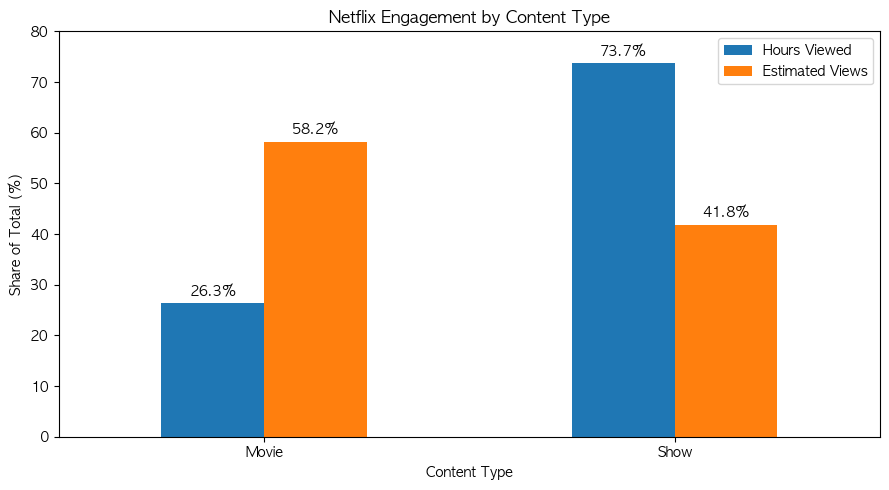

In [118]:
ax = type_comparison_display.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Netflix Engagement by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Share of Total (%)")
plt.xticks(rotation=0)
plt.ylim(0, 80)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

### Movies vs Shows

Shows account for approximately 73.7% of title-level viewing hours from 2023 H2 onwards, compared with 26.3% for Movies. However, the pattern reverses when using Netflix's Views metric: Movies account for approximately 58.2% of estimated views, compared with 41.8% for Shows.

Runtime helps explain this difference. The median runtime is approximately 320 minutes for Shows compared with 104 minutes for Movies. Longer runtimes allow Shows to accumulate substantially more viewing hours per view.

This demonstrates the importance of metric selection: Hours Viewed favours longer-form content, while Netflix's Views metric adjusts viewing hours relative to runtime. Views should not be interpreted as a count of unique viewers.

Do titles available globally generate more engagement than titles that are not globally available?

In [119]:
df_titles["Available Globally?"].value_counts()

Available Globally?
No     83197
Yes    32755
Name: count, dtype: int64

In [120]:
median_hours_global = (
    df_titles.groupby("Available Globally?")["Hours Viewed"]
    .median()
)

median_hours_global / 1_000_000

Available Globally?
No     0.7
Yes    2.3
Name: Hours Viewed, dtype: float64

In [121]:
median_hours_global.apply(
    lambda x: f"{x:,.0f} hours"
)

Available Globally?
No       700,000 hours
Yes    2,300,000 hours
Name: Hours Viewed, dtype: str

In [122]:
global_hours_ratio = (
    median_hours_global["Yes"] /
    median_hours_global["No"]
)

print(f"{global_hours_ratio:.1f} times")

3.3 times


In [123]:
median_views_global = (
    df_titles.groupby("Available Globally?")["Views"]
    .median()
)

median_views_global.apply(
    lambda x: f"{x:,.0f} views"
)

Available Globally?
No     200,000 views
Yes    700,000 views
Name: Views, dtype: str

In [124]:
global_views_ratio = (
    median_views_global["Yes"] /
    median_views_global["No"]
)

print(f"{global_views_ratio:.1f} times")

3.5 times


In [125]:
global_comparison = pd.Series({
    "Hours Viewed": global_hours_ratio,
    "Estimated Views": global_views_ratio
})

global_comparison.round(1)

Hours Viewed       3.3
Estimated Views    3.5
dtype: float64

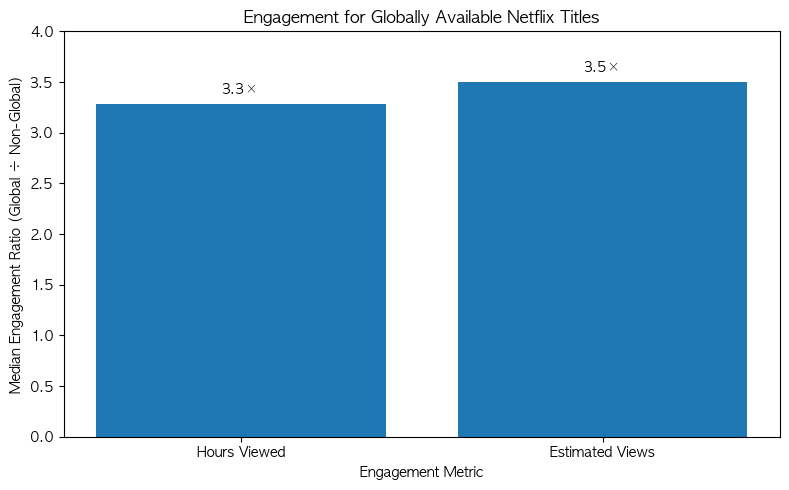

In [126]:
plt.figure(figsize=(8, 5))

plt.bar(
    global_comparison.index,
    global_comparison.values
)

plt.title("Engagement for Globally Available Netflix Titles")
plt.xlabel("Engagement Metric")
plt.ylabel("Median Engagement Ratio (Global ÷ Non-Global)")
plt.ylim(0, 4)

for label, value in global_comparison.items():
    plt.text(
        label,
        value + 0.1,
        f"{value:.1f}×",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Global Availability and Engagement

Globally available titles show substantially higher median engagement than titles that are not available globally. The median Hours Viewed per title-period observation is approximately 3.3 times higher for globally available titles, while median Estimated Views are approximately 3.5 times higher.

The similar result across both engagement measures suggests a strong association between global availability and higher engagement. However, this should not be interpreted as evidence that global availability causes higher viewing, as other factors such as title popularity, marketing, language availability and content characteristics may also influence engagement.

Does older Netflix content still attract substantial viewing?

In [127]:
df_titles["Release Date"].notna().value_counts()

Release Date
False    78840
True     37112
Name: count, dtype: int64

In [128]:
print("Earliest:", df_titles["Release Date"].min())
print("Latest:", df_titles["Release Date"].max())

Earliest: 2010-04-01 00:00:00
Latest: 2026-06-29 00:00:00


In [130]:
df_titles["Release Year"] = (
    df_titles["Release Date"].dt.year.astype("Int64")
)
df_titles["Release Year"].value_counts().sort_index()

Release Year
2010      56
2011      21
2012       7
2013      72
2014     155
2015     466
2016    1093
2017    1968
2018    3300
2019    4041
2020    4744
2021    5087
2022    6044
2023    4341
2024    3039
2025    2197
2026     481
Name: count, dtype: Int64

In [131]:
df_titles["Report Year"] = (
    df_titles["Report Period"]
    .str[:4]
    .astype("int64")
)

df_titles["Report Year"].value_counts().sort_index()

Report Year
2023    34208
2024    31724
2025    32650
2026    17370
Name: count, dtype: int64

In [132]:
df_titles["Content Age"] = (
    df_titles["Report Year"] - df_titles["Release Year"]
)

df_titles["Content Age"].describe()

count     37112.0
mean     3.534382
std      2.517338
min           0.0
25%           1.0
50%           3.0
75%           5.0
max          16.0
Name: Content Age, dtype: Float64

In [133]:
print(f"Median content age: {df_titles['Content Age'].median():.0f} years")
print(f"Maximum content age: {df_titles['Content Age'].max():.0f} years")

Median content age: 3 years
Maximum content age: 16 years


In [134]:
df_titles["Age Group"] = pd.cut(
    df_titles["Content Age"],
    bins=[-1, 1, 3, 5, 10, 16],
    labels=[
        "0–1 years",
        "2–3 years",
        "4–5 years",
        "6–10 years",
        "11–16 years"
    ]
)

df_titles["Age Group"].value_counts().sort_index()

Age Group
0–1 years       9337
2–3 years      10518
4–5 years       9086
6–10 years      7931
11–16 years      240
Name: count, dtype: int64

In [135]:
median_hours_by_age = (
    df_titles.groupby(
        "Age Group",
        observed=True
    )["Hours Viewed"]
    .median()
)

median_hours_by_age.apply(
    lambda x: f"{x:,.0f} hours"
)

Age Group
0–1 years      5,200,000 hours
2–3 years      2,000,000 hours
4–5 years      1,600,000 hours
6–10 years     1,400,000 hours
11–16 years    4,600,000 hours
Name: Hours Viewed, dtype: str

In [136]:
oldest_titles = df_titles[
    df_titles["Age Group"] == "11–16 years"
]

oldest_titles[
    ["Title", "Release Year", "Report Period", "Hours Viewed"]
].nlargest(10, "Hours Viewed")

,Title,Release Year,Report Period,Hours Viewed
101,La Reina del Sur: Season 1,2011,2023 H1,94700000
98652,Peaky Blinders: Season 1,2014,2026 H1,78400000
98709,Peaky Blinders: Season 2,2014,2026 H1,58500000
34767,Orange Is the New Black: Season 1,2013,2024 H1,47400000
82286,Peaky Blinders: Season 1,2014,2025 H2,47300000
50929,Orange Is the New Black: Season 1,2013,2024 H2,46400000
66162,Peaky Blinders: Season 1,2014,2025 H1,41600000
66648,Orange Is the New Black: Season 1,2013,2025 H1,40300000
20360,La Reina del Sur: Season 1,2011,2023 H2,38000000
36408,La Reina del Sur: Season 1,2011,2024 H1,37900000


In [137]:
median_views_by_age = (
    df_titles.groupby(
        "Age Group",
        observed=True
    )["Views"]
    .median()
)

median_views_by_age.apply(
    lambda x: f"{x:,.0f} views"
)

Age Group
0–1 years      1,500,000 views
2–3 years        600,000 views
4–5 years        500,000 views
6–10 years       400,000 views
11–16 years    1,100,000 views
Name: Views, dtype: str

In [138]:
age_comparison = pd.DataFrame({
    "Hours Viewed (Millions)": median_hours_by_age / 1_000_000,
    "Netflix Views (Millions)": median_views_by_age / 1_000_000
})

age_comparison.round(1)

,Hours Viewed (Millions),Netflix Views (Millions)
Age Group,,
0–1 years,5.2,1.5
2–3 years,2.0,0.6
4–5 years,1.6,0.5
6–10 years,1.4,0.4
11–16 years,4.6,1.1


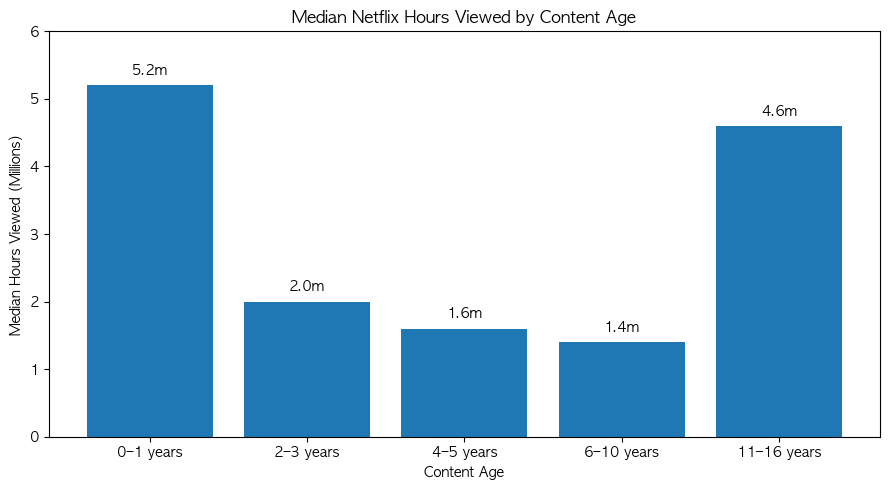

In [139]:
plt.figure(figsize=(9, 5))

plt.bar(
    median_hours_by_age.index,
    median_hours_by_age.values / 1_000_000
)

plt.title("Median Netflix Hours Viewed by Content Age")
plt.xlabel("Content Age")
plt.ylabel("Median Hours Viewed (Millions)")
plt.ylim(0, 6)

for age, value in median_hours_by_age.items():
    plt.text(
        age,
        value / 1_000_000 + 0.15,
        f"{value / 1_000_000:.1f}m",
        ha="center"
    )

plt.tight_layout()
plt.show()

### Content Age and Catalogue Engagement

For titles with a known release date, median engagement generally declines as content ages. Titles aged 0–1 years generated a median of approximately 5.2 million viewing hours per title-period observation, falling to 1.4 million for titles aged 6–10 years.

However, the small group of titles aged 11–16 years recorded a much higher median of 4.6 million hours. Inspection of this group identified enduring catalogue titles such as *Peaky Blinders*, *Orange Is the New Black*, and *La Reina del Sur* that continued to attract substantial viewing many years after release.

This oldest category contains only 240 observations, so the result should not be interpreted as evidence that older content generally performs better. Release-date analysis is also limited to the 37,112 observations for which a release date is available.

Has the Movies vs Shows pattern changed over time?

In [140]:
hours_type_period = (
    df_titles.groupby(
        ["Report Period", "Content Type"]
    )["Hours Viewed"]
    .sum()
    .unstack()
)

hours_type_period / 1_000_000_000

Content Type,Movie,Show
Report Period,,
2023 H2,25.0677,64.9554
2024 H1,25.7435,68.2600
2024 H2,25.9057,68.2094
2025 H1,24.0582,71.1283
2025 H2,24.7163,70.7343
2026 H1,23.2073,73.5973


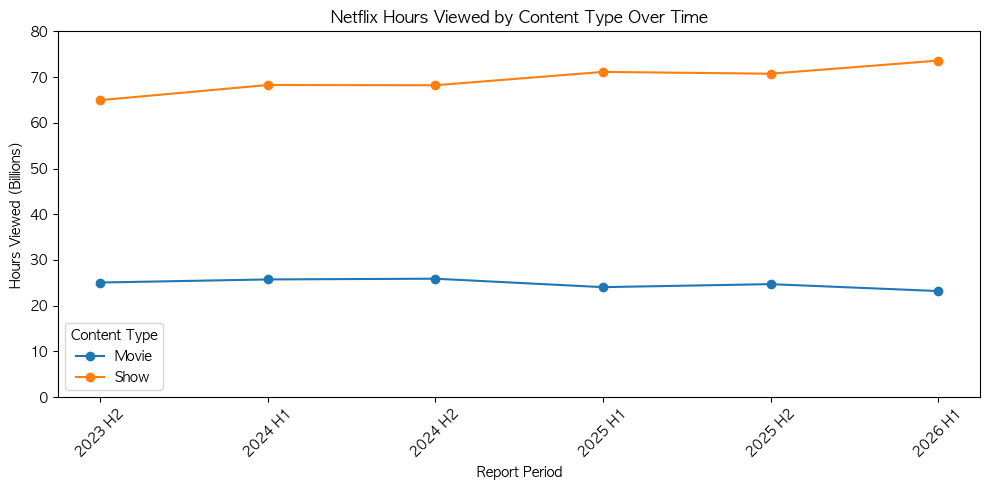

In [141]:
hours_type_period_billions = (
    hours_type_period / 1_000_000_000
)

hours_type_period_billions.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Netflix Hours Viewed by Content Type Over Time")
plt.xlabel("Report Period")
plt.ylabel("Hours Viewed (Billions)")
plt.ylim(0, 80)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [142]:
movie_change = (
    hours_type_period_billions["Movie"].iloc[-1]
    / hours_type_period_billions["Movie"].iloc[0]
    - 1
) * 100

show_change = (
    hours_type_period_billions["Show"].iloc[-1]
    / hours_type_period_billions["Show"].iloc[0]
    - 1
) * 100

print(f"Movies: {movie_change:.1f}%")
print(f"Shows: {show_change:.1f}%")

Movies: -7.4%
Shows: 13.3%


### Movies vs Shows Over Time

The gap between Movie and Show viewing hours widened between 2023 H2 and 2026 H1. Reported viewing hours for Shows increased from approximately 65.0 billion to 73.6 billion, an increase of 13.3%.

Over the same period, Movie viewing hours declined from approximately 25.1 billion to 23.2 billion, a decrease of 7.4%.

This indicates a growing difference in reported viewing hours between the two content types. However, Hours Viewed is influenced by runtime, so the trend should not be interpreted as evidence that viewers are necessarily switching from Movies to Shows.

## Key Findings

The exploratory analysis identified several important patterns in Netflix engagement data:

1. **Overall viewing remained relatively stable before increasing.** Reported viewing hours fell by 3.7% in 2023 H2 before recovering, reaching approximately 97.7 billion hours in 2026 H1. Overall viewing hours increased by approximately 4.5% between 2023 H1 and 2026 H1.

2. **A small proportion of content accounts for a large share of engagement.** The top 1% of title-period observations generated 24.8% of title-level viewing hours, while the top 5% generated 52.8% and the top 10% generated 68.6%.

3. **Shows dominate Hours Viewed, while Movies generate more Netflix Views.** From 2023 H2 onwards, Shows accounted for 73.7% of title-level viewing hours, while Movies accounted for 58.2% of Netflix Views. The substantially longer median runtime of Shows helps explain this difference.

4. **Global availability is associated with substantially higher engagement.** Globally available titles recorded 3.3 times the median Hours Viewed and 3.5 times the median Netflix Views of titles that were not globally available.

5. **New releases generally attract stronger engagement, but some older catalogue titles remain highly durable.** Median Hours Viewed declined as content aged from 0–1 years to 6–10 years, while a small group of 11–16-year-old titles continued to generate substantial engagement.

6. **Show viewing hours increased while Movie viewing hours declined.** Between 2023 H2 and 2026 H1, Show viewing hours increased by 13.3%, while Movie viewing hours decreased by 7.4%.

## Limitations

- Netflix's reporting methodology and available fields changed across reporting periods, so comparisons over time should be interpreted carefully.
- Views and Content Type are unavailable for 2023 H1.
- Release Date is available for only 37,112 of the 115,952 individual title-period observations.
- Netflix Views represent viewing hours divided by runtime and should not be interpreted as unique viewers.
- The same title may appear in multiple reporting periods, so observations represent title-period combinations rather than unique titles.
- The analysis identifies associations and patterns but does not establish causation.